# Categorical Statistical Analysis

This notebook evaluates the statistical association between categorical
employee characteristics and employee attrition.

The analysis uses Chi-Square Tests of Independence to determine whether
categorical variables are statistically associated with attrition.

Cramér's V is then used to measure the practical strength of the associations.

The analysis complements the numerical statistical analysis conducted in
the exploratory data analysis notebook.

## 1. Load Clean Dataset

The cleaned HR employee attrition dataset is loaded for categorical
statistical analysis.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

file_path = "../data/processed/hr_employee_attrition_clean.csv"

df = pd.read_csv(file_path)

df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [19]:
df.shape

(1470, 32)

In [3]:
df.columns.tolist()

['age',
 'attrition',
 'business_travel',
 'daily_rate',
 'department',
 'distance_from_home',
 'education',
 'education_field',
 'employee_number',
 'environment_satisfaction',
 'gender',
 'hourly_rate',
 'job_involvement',
 'job_level',
 'job_role',
 'job_satisfaction',
 'marital_status',
 'monthly_income',
 'monthly_rate',
 'num_companies_worked',
 'over_time',
 'percent_salary_hike',
 'performance_rating',
 'relationship_satisfaction',
 'stock_option_level',
 'total_working_years',
 'training_times_last_year',
 'work_life_balance',
 'years_at_company',
 'years_in_current_role',
 'years_since_last_promotion',
 'years_with_curr_manager']

## 2. Categorical Variables Selection

The selected variables represent categorical or ordinal employee characteristics
that may be associated with employee attrition.

The analysis focuses on variables with clear HR and business relevance,
including workload, job characteristics, employee satisfaction, demographic
characteristics, and performance-related factors.

Ordinal variables such as job satisfaction, job involvement, and work-life
balance are treated as categorical variables for the Chi-Square analysis
because the test evaluates whether the distribution of attrition differs
across their categories.

In [9]:
categorical_analysis_cols = [
    "over_time",
    "business_travel",
    "department",
    "education_field",
    "job_role",
    "marital_status",
    "gender",
    "job_satisfaction",
    "environment_satisfaction",
    "job_involvement",
    "relationship_satisfaction",
    "work_life_balance",
    "stock_option_level",
    "performance_rating"
]

In [10]:
categorical_summary = pd.DataFrame({
    "column": categorical_analysis_cols,
    "unique_count": [
        df[col].nunique()
        for col in categorical_analysis_cols
    ]
})

categorical_summary

,column,unique_count
0,over_time,2
1,business_travel,3
2,department,3
3,education_field,6
4,job_role,9
5,marital_status,3
6,gender,2
7,job_satisfaction,4
8,environment_satisfaction,4
9,job_involvement,4


## 3. Chi-Square Test of Independence

The Chi-Square Test of Independence is used to determine whether there is
a statistically significant association between each categorical variable
and employee attrition.

Null Hypothesis (H₀):

There is no statistically significant association between the categorical
variable and employee attrition.

Alternative Hypothesis (H₁):

There is a statistically significant association between the categorical
variable and employee attrition.

Significance level:

α = 0.05

In [11]:
from scipy.stats import chi2_contingency

chi_square_results = []

for col in categorical_analysis_cols:
    contingency_table = pd.crosstab(
        df[col],
        df["attrition"]
    )

    chi2_statistic, p_value, degrees_of_freedom, expected = (
        chi2_contingency(contingency_table)
    )

    chi_square_results.append({
        "column": col,
        "chi2_statistic": chi2_statistic,
        "p_value": p_value,
        "degrees_of_freedom": degrees_of_freedom,
        "significant": p_value < 0.05
    })

chi_square_results = (
    pd.DataFrame(chi_square_results)
    .sort_values("p_value")
    .reset_index(drop=True)
)

chi_square_results

,column,chi2_statistic,p_value,degrees_of_freedom,significant
0,over_time,87.564294,8.158424e-21,1,True
1,job_role,86.190254,2.752482e-15,8,True
2,stock_option_level,60.598301,4.379390e-13,3,True
3,marital_status,46.163677,9.455511e-11,2,True
4,job_involvement,28.492021,2.863181e-06,3,True
5,business_travel,24.182414,5.608614e-06,2,True
6,environment_satisfaction,22.503881,5.123469e-05,3,True
7,job_satisfaction,17.505077,5.563005e-04,3,True
8,work_life_balance,16.325097,9.725699e-04,3,True
9,department,10.796007,4.525607e-03,2,True


In [12]:
chi_square_assumptions = []

for col in categorical_analysis_cols:
    contingency_table = pd.crosstab(
        df[col],
        df["attrition"]
    )

    _, _, _, expected = chi2_contingency(contingency_table)

    chi_square_assumptions.append({
        "column": col,
        "minimum_expected_frequency": expected.min(),
        "cells_below_5": (expected < 5).sum(),
        "total_cells": expected.size
    })

chi_square_assumptions = pd.DataFrame(chi_square_assumptions)

chi_square_assumptions

,column,minimum_expected_frequency,cells_below_5,total_cells
0,over_time,67.069388,0,4
1,business_travel,24.183673,0,6
2,department,10.157143,0,6
3,education_field,4.353061,1,12
4,job_role,8.383673,0,18
5,marital_status,52.720408,0,6
6,gender,94.800000,0,4
7,job_satisfaction,45.142857,0,8
8,environment_satisfaction,45.787755,0,8
9,job_involvement,13.381633,0,8


### Expected Frequency Diagnostic

This section inspects the expected frequencies for `education_field`, which contains one cell with an expected frequency below 5.

In [13]:
contingency_table = pd.crosstab(
    df["education_field"],
    df["attrition"]
)

chi2_statistic, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_table.round(2)

attrition,No,Yes
education_field,,
Human Resources,22.65,4.35
Life Sciences,508.30,97.70
Marketing,133.37,25.63
Medical,389.19,74.81
Other,68.78,13.22
Technical Degree,110.72,21.28


## 4. Multiple Testing Correction

Because multiple Chi-Square tests are performed simultaneously, a Bonferroni
correction is applied to control the family-wise error rate.

The correction reduces the probability of obtaining false-positive results
when evaluating multiple categorical variables against employee attrition.

The adjusted p-values are used to determine which associations remain
statistically significant after multiple testing correction.

In [14]:
from statsmodels.stats.multitest import multipletests

reject, p_value_adjusted, _, _ = multipletests(
    chi_square_results["p_value"],
    alpha=0.05,
    method="bonferroni"
)

chi_square_results["adjusted_p_value"] = p_value_adjusted
chi_square_results["significant_adjusted"] = reject

chi_square_results

,column,chi2_statistic,p_value,degrees_of_freedom,significant,adjusted_p_value,significant_adjusted
0,over_time,87.564294,8.158424e-21,1,True,1.142179e-19,True
1,job_role,86.190254,2.752482e-15,8,True,3.853474e-14,True
2,stock_option_level,60.598301,4.379390e-13,3,True,6.131146e-12,True
3,marital_status,46.163677,9.455511e-11,2,True,1.323772e-09,True
4,job_involvement,28.492021,2.863181e-06,3,True,4.008453e-05,True
5,business_travel,24.182414,5.608614e-06,2,True,7.852060e-05,True
6,environment_satisfaction,22.503881,5.123469e-05,3,True,7.172856e-04,True
7,job_satisfaction,17.505077,5.563005e-04,3,True,7.788206e-03,True
8,work_life_balance,16.325097,9.725699e-04,3,True,1.361598e-02,True
9,department,10.796007,4.525607e-03,2,True,6.335849e-02,False


## 5. Effect Size — Cramér's V

Statistical significance indicates whether an association between a
categorical variable and employee attrition is unlikely to have occurred
by chance.

However, statistical significance does not indicate the practical strength
of the association.

Cramér's V is therefore calculated to measure the effect size of the
association between each categorical variable and employee attrition.

For this analysis, the following thresholds are used as a practical guideline for interpreting Cramér's V:

* V < 0.10 → Negligible
* 0.10 ≤ V < 0.30 → Small
* 0.30 ≤ V < 0.50 → Medium
* V ≥ 0.50 → Large

These thresholds are used as practical guidelines rather than strict universal standards.

Cramér's V is interpreted together with the Bonferroni-adjusted statistical
significance results.

In [15]:
def calculate_cramers_v(contingency_table):
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    min_dimension = min(contingency_table.shape) - 1

    return np.sqrt(
        chi2_statistic / (n * min_dimension)
    )

In [16]:
effect_size_results = []

for col in categorical_analysis_cols:
    contingency_table = pd.crosstab(
        df[col],
        df["attrition"]
    )

    cramers_v = calculate_cramers_v(contingency_table)

    if cramers_v < 0.10:
        effect_interpretation = "Negligible"
    elif cramers_v < 0.30:
        effect_interpretation = "Small"
    elif cramers_v < 0.50:
        effect_interpretation = "Medium"
    else:
        effect_interpretation = "Large"

    effect_size_results.append({
        "column": col,
        "cramers_v": cramers_v,
        "effect_size": effect_interpretation
    })

effect_size_df = (
    pd.DataFrame(effect_size_results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

effect_size_df

,column,cramers_v,effect_size
0,over_time,0.244065,Small
1,job_role,0.242142,Small
2,stock_option_level,0.203035,Small
3,marital_status,0.177211,Small
4,job_involvement,0.139220,Small
5,business_travel,0.128260,Small
6,environment_satisfaction,0.123729,Small
7,job_satisfaction,0.109125,Small
8,work_life_balance,0.105383,Small
9,education_field,0.104409,Small


In [17]:
categorical_statistical_summary = (
    chi_square_results[
        [
            "column",
            "chi2_statistic",
            "p_value",
            "adjusted_p_value",
            "significant_adjusted"
        ]
    ]
    .merge(
        effect_size_df,
        on="column",
        how="left"
    )
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

categorical_statistical_summary

,column,chi2_statistic,p_value,adjusted_p_value,significant_adjusted,cramers_v,effect_size
0,over_time,87.564294,8.158424e-21,1.142179e-19,True,0.244065,Small
1,job_role,86.190254,2.752482e-15,3.853474e-14,True,0.242142,Small
2,stock_option_level,60.598301,4.379390e-13,6.131146e-12,True,0.203035,Small
3,marital_status,46.163677,9.455511e-11,1.323772e-09,True,0.177211,Small
4,job_involvement,28.492021,2.863181e-06,4.008453e-05,True,0.139220,Small
5,business_travel,24.182414,5.608614e-06,7.852060e-05,True,0.128260,Small
6,environment_satisfaction,22.503881,5.123469e-05,7.172856e-04,True,0.123729,Small
7,job_satisfaction,17.505077,5.563005e-04,7.788206e-03,True,0.109125,Small
8,work_life_balance,16.325097,9.725699e-04,1.361598e-02,True,0.105383,Small
9,education_field,16.024674,6.773980e-03,9.483572e-02,False,0.104409,Small


## 6. Statistical Findings

The Chi-Square analysis identified statistically significant associations
between employee attrition and 11 of the 14 categorical variables before
multiple testing correction.

After applying the Bonferroni correction, 9 variables remained statistically
significantly associated with attrition: overtime, job role, stock option
level, marital status, job involvement, business travel, environment
satisfaction, job satisfaction, and work-life balance.

Among these variables, overtime showed the strongest association with
attrition based on Cramér's V (V = 0.244), followed closely by job role
(V = 0.242) and stock option level (V = 0.203). However, all statistically
significant associations had small effect sizes.

Department and education field were statistically significant before
multiple testing correction but did not remain significant after Bonferroni
adjustment. Relationship satisfaction, gender, and performance rating were
not statistically significant after correction.

These results indicate that several categorical employee characteristics
are statistically associated with attrition, but the magnitude of these
associations is relatively small. Therefore, statistical significance should
not be interpreted as evidence of strong or causal relationships.

`education_field` had one expected frequency below 5, so its Chi-Square result should be interpreted with some caution. It was not statistically significant after Bonferroni correction.

## 7. Cramér's V Visualization

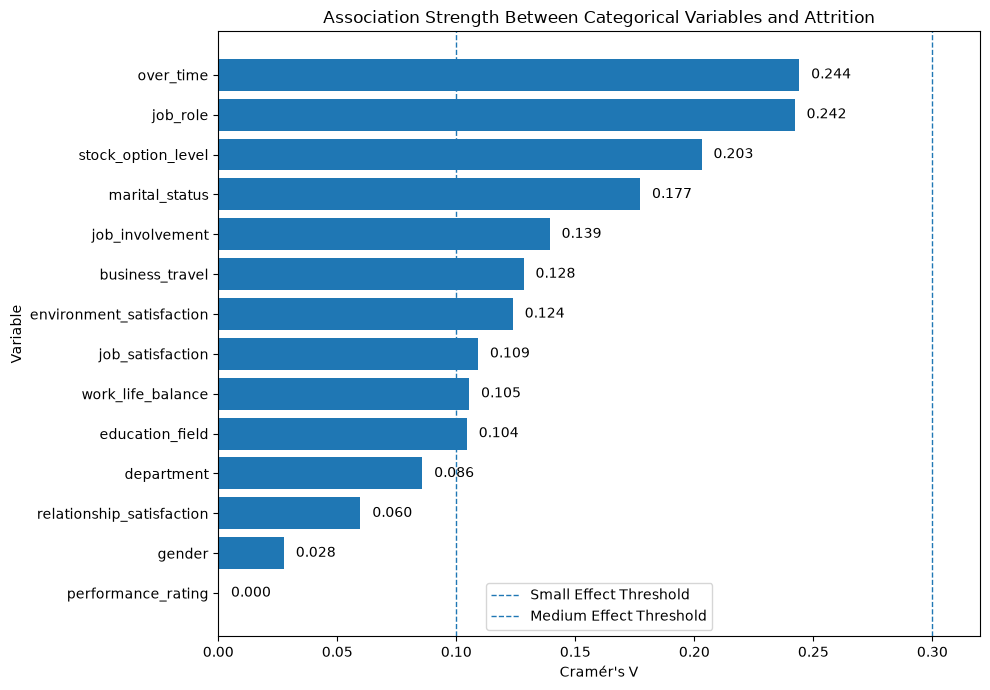

In [21]:
cramers_v_plot = (
    categorical_statistical_summary
    .sort_values("cramers_v", ascending=True)
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    cramers_v_plot["column"],
    cramers_v_plot["cramers_v"]
)

plt.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="Small Effect Threshold"
)

plt.axvline(
    0.30,
    linestyle="--",
    linewidth=1,
    label="Medium Effect Threshold"
)

plt.xlabel("Cramér's V")
plt.ylabel("Variable")
plt.title("Association Strength Between Categorical Variables and Attrition")

for bar, value in zip(bars, cramers_v_plot["cramers_v"]):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(0, max(cramers_v_plot["cramers_v"].max() * 1.15, 0.32))

plt.legend()

plt.tight_layout()
plt.show()

## 8. Business Interpretation

The statistical analysis indicates that several categorical employee characteristics
have statistically significant associations with employee attrition after Bonferroni
correction.

Overtime shows the strongest association with attrition among the analyzed categorical
variables, with a Cramér's V of 0.244. Job Role follows with a Cramér's V of 0.242,
while Stock Option Level and Marital Status show Cramér's V values of 0.203 and 0.177,
respectively. These variables may therefore provide useful segmentation dimensions
when examining employee attrition patterns.

Job Involvement, Business Travel, Environment Satisfaction, Job Satisfaction, and
Work-Life Balance also remain statistically significant after multiple-testing
correction, although their association strengths are relatively small.

It is important to distinguish statistical significance from practical importance.
Although several variables show statistically significant associations with
attrition, all observed effect sizes are relatively small. Therefore, these factors
should not be interpreted as strong standalone determinants of employee attrition.

Education Field and Department are not statistically significant after Bonferroni
correction, despite having significant unadjusted p-values. This indicates that their
initial associations with attrition may not remain statistically reliable after
accounting for multiple comparisons.

Relationship Satisfaction, Gender, and Performance Rating show no statistically
significant association with attrition in this analysis.

From a business perspective, the findings suggest that HR retention analysis should
pay particular attention to overtime, job role, stock option level, marital status,
and employee experience-related factors such as job involvement and job satisfaction.
However, these results describe associations rather than causal relationships and
should be combined with descriptive analysis and employee risk profiling before
forming retention strategies.

## 9. Analysis Limitations

Several limitations should be considered when interpreting the results of this categorical statistical analysis.

1. **Association does not imply causation**

   The Chi-Square Test of Independence identifies statistical associations between categorical variables and employee attrition. However, the results do not establish that the identified variables directly cause employees to leave.

2. **Effect sizes are relatively small**

   Although several variables remain statistically significant after Bonferroni correction, their Cramér's V values indicate small effect sizes. Therefore, these variables should not be considered strong standalone predictors of employee attrition.

3. **Multiple testing correction is conservative**

   The Bonferroni correction reduces the likelihood of false-positive findings but can also reduce statistical power. Some variables that show meaningful unadjusted associations may no longer meet the adjusted significance threshold.

4. **Categorical analysis does not capture interactions**

   Each categorical variable is tested independently against attrition. The analysis does not evaluate whether combinations or interactions between variables may have stronger relationships with employee attrition.

5. **Ordinal variables are treated as categorical**

   Variables such as Job Satisfaction, Environment Satisfaction, Job Involvement, and Work-Life Balance are ordinal in nature but are treated as categorical variables in the Chi-Square analysis. This approach evaluates differences in category distributions but does not account for the inherent ordering of the categories.

6. **One assumption warning was identified**

   The `education_field` contingency table contains one expected frequency below 5. Therefore, its Chi-Square result should be interpreted with some caution. This variable did not remain statistically significant after Bonferroni correction.

7. **Dataset-specific findings**

   The analysis is based on the available HR employee attrition dataset and reflects patterns within this dataset. The findings may not generalize directly to other organizations, industries, or employee populations.

Overall, the categorical statistical analysis should be considered a supporting analytical component rather than a standalone attrition prediction method. The findings are most useful when combined with descriptive analysis, numerical statistical testing, and employee risk segmentation to provide a more comprehensive view of attrition patterns.